<!-- launch-badges -->
<a href="https://colab.research.google.com/github/laban254/ml-for-infrastructure/blob/main/05_sre_applications/mlops_tracking/mlflow_basics.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
&nbsp;
<a href="https://mybinder.org/v2/gh/laban254/ml-for-infrastructure/main?urlpath=lab/tree/05_sre_applications/mlops_tracking/mlflow_basics.ipynb" target="_blank"><img src="https://mybinder.org/badge_logo.svg" alt="Open in Binder"/></a>

> ▶️ **Run this notebook live** — no install needed. Click a badge above to open it in a free cloud runtime.

# Tracking Experiments with MLflow

## Objectives
- Bridge the gap between "Data Science" (building models in a black box) and "MLOps" (tracking models like operational software).
- Integrate **MLflow** into a Scikit-Learn training script to automatically log hyperparameters, metrics, and models.

## Dataset
- We will use a synthetic dataset for a binary classification task (e.g., "Will this server crash in the next 10 minutes?").

## Expected Outcome
- A functional Python script that logs training runs. You can view these runs by typing `mlflow ui` in your terminal.

## Challenge
- Can you modify the logging code to also track the model's signature (the expected input/output schema) using `mlflow.models.signature.infer_signature`?

In [1]:
# !pip install mlflow scikit-learn pandas matplotlib

In [2]:
import mlflow
import mlflow.sklearn
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.datasets import make_classification

# Set up MLflow tracking URI (default is a local ./mlruns directory)
mlflow.set_tracking_uri("sqlite:///mlruns.db") 
mlflow.set_experiment("Server_Crash_Prediction")

2026/06/20 11:16:12 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/06/20 11:16:13 INFO mlflow.store.db.utils: Updating database tables


INFO  [alembic.runtime.migration] Context impl SQLiteImpl.


INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


INFO  [alembic.runtime.migration] Running upgrade  -> 451aebb31d03, add metric step


...

INFO  [alembic.runtime.migration] Running upgrade 5b0e9adcef9c -> 4465047574b1, increase max dataset schema size


INFO  [alembic.runtime.migration] Context impl SQLiteImpl.


INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


2026/06/20 11:16:13 INFO mlflow.tracking.fluent: Experiment with name 'Server_Crash_Prediction' does not exist. Creating a new experiment.


<Experiment: artifact_location='/home/kibe/pro/engineeringhub/data-science-and-ml-exercises/05_sre_applications/mlops_tracking/mlruns/1', creation_time=1781943373553, experiment_id='1', last_update_time=1781943373553, lifecycle_stage='active', name='Server_Crash_Prediction', tags={}>

### 1. The Scenario
Every time you train a model, you typically try different hyperparameters. Without MLflow, you end up with spreadsheets or messy notebook cells trying to remember what worked best.

In [3]:
# Generate Synthetic SRE Data (Features could be latency, memory util, disk IO)
X, y = make_classification(n_samples=2000, n_features=10, n_informative=5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 2. The MLflow Context Manager
By wrapping our training code in `with mlflow.start_run():`, everything inside that block is grouped into a single tracked "Run".

In [4]:
def train_and_log_model(n_estimators, max_depth):
    with mlflow.start_run():
        # 1. Log the parameters we are testing
        mlflow.log_param("n_estimators", n_estimators)
        mlflow.log_param("max_depth", max_depth)
        
        # 2. Train the model
        clf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
        clf.fit(X_train, y_train)
        
        # 3. Evaluate
        predictions = clf.predict(X_test)
        acc = accuracy_score(y_test, predictions)
        prec = precision_score(y_test, predictions)
        rec = recall_score(y_test, predictions)
        
        # 4. Log the metrics
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("precision", prec)
        mlflow.log_metric("recall", rec)
        
        # 5. Log the actual model artifact!
        mlflow.sklearn.log_model(clf, "random_forest_model")
        
        print(f"Run Complete! | estimators: {n_estimators}, depth: {max_depth} | Acc: {acc:.3f} | Prec: {prec:.3f}")

# Let's simulate a hyperparameter search
train_and_log_model(50, 5)
train_and_log_model(100, 10)
train_and_log_model(200, None)

2026/06/20 11:16:18 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Run Complete! | estimators: 50, depth: 5 | Acc: 0.880 | Prec: 0.907


2026/06/20 11:16:21 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Run Complete! | estimators: 100, depth: 10 | Acc: 0.907 | Prec: 0.928


2026/06/20 11:16:26 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Run Complete! | estimators: 200, depth: None | Acc: 0.912 | Prec: 0.929


### 3. Viewing the Results
Now that we have logged 3 runs, you can open your terminal, navigate to this directory, and type:

```bash
mlflow ui
```

This will launch a web dashboard on `http://localhost:5000` where you can compare the runs, visualize the metrics, and download the exact `.pkl` model file that produced the best results.

### 4. A proper sweep — with model *signatures*

The runs above logged params, metrics, and the model. For real deployment you also want the model's **signature** — the expected input/output schema — so the serving layer can validate incoming requests. Let's run a small grid and log a signature plus an input example with each model.

In [5]:
from mlflow.models.signature import infer_signature

def train_with_signature(n_estimators, max_depth):
    with mlflow.start_run(run_name=f'rf_{n_estimators}_{max_depth}'):
        mlflow.set_tag('phase', 'sweep')
        mlflow.log_params({'n_estimators': n_estimators, 'max_depth': max_depth})
        clf = RandomForestClassifier(n_estimators=n_estimators,
                                     max_depth=max_depth, random_state=42)
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        mlflow.log_metric('accuracy', accuracy_score(y_test, preds))
        mlflow.log_metric('precision', precision_score(y_test, preds))
        mlflow.log_metric('recall', recall_score(y_test, preds))
        # Signature = schema of inputs -> outputs, inferred from real data
        signature = infer_signature(X_train, clf.predict(X_train))
        mlflow.sklearn.log_model(clf, 'model', signature=signature,
                                 input_example=X_train[:2])

for n in (50, 100, 200):
    for d in (3, 8):
        train_with_signature(n, d)
print('Logged 6 runs with signatures.')

Logged 6 runs with signatures.


### 5. Compare every run *inline* (no UI required)

`mlflow ui` is great locally, but you can also query the tracking store programmatically. This is what a CI gate or an automated model-promotion job actually does — pull every run, rank them, and pick a winner. Here we optimise for **recall** (in a crash-prediction model, a missed outage is far worse than a false alarm).

In [6]:
# Only the tagged sweep runs (keeps this analysis reproducible run-to-run)
runs = mlflow.search_runs(filter_string="tags.phase = 'sweep'",
                          order_by=['metrics.recall DESC'])
cols = ['run_id', 'params.n_estimators', 'params.max_depth',
        'metrics.recall', 'metrics.precision', 'metrics.accuracy']
leaderboard = runs[[c for c in cols if c in runs.columns]].head(6)
leaderboard

,run_id,params.n_estimators,params.max_depth,metrics.recall,metrics.precision,metrics.accuracy
0,ebbc4557a9a04b48a15fbfdb4c1805d2,200,8,0.902326,0.910798,0.9000
1,acdf5b0951ce43b2af22a0fef46ef0f3,100,8,0.902326,0.915094,0.9025
2,7a54afb090ce4c3aa95ec99f5d8fc29f,50,8,0.879070,0.908654,0.8875
3,6684be9fce6f4934add862eafab31196,200,3,0.827907,0.881188,0.8475
4,0eb50c2c67c342dfba797c88dee062f1,100,3,0.827907,0.872549,0.8425
5,6ae9cf049ff340b2a37158cacbd94a42,50,3,0.818605,0.871287,0.8375


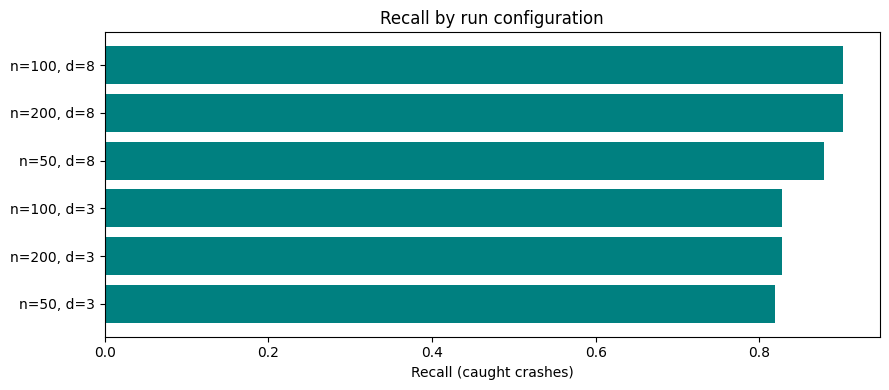

In [7]:
import matplotlib.pyplot as plt

plot_df = runs.dropna(subset=['metrics.recall']).copy()
plot_df['label'] = ('n=' + plot_df['params.n_estimators'].astype(str)
                    + ', d=' + plot_df['params.max_depth'].astype(str))
plot_df = plot_df.sort_values('metrics.recall')
plt.figure(figsize=(9, 4))
plt.barh(plot_df['label'], plot_df['metrics.recall'], color='teal')
plt.xlabel('Recall (caught crashes)'); plt.title('Recall by run configuration')
plt.tight_layout(); plt.show()

### 6. Reload the winning model and serve a prediction

The whole point of tracking is reproducibility: weeks later you can pull the *exact* model that won, by its run ID, and run it — no retraining, no guessing which `.pkl` was which.

In [8]:
best_run_id = runs.sort_values('metrics.recall', ascending=False).iloc[0]['run_id']
best_model = mlflow.sklearn.load_model(f'runs:/{best_run_id}/model')
sample = X_test[:5]
print(f'Reloaded model from run {best_run_id[:8]}...')
print('Predictions on 5 held-out servers:', best_model.predict(sample))
print('Actual labels:                    ', y_test[:5])

Reloaded model from run ebbc4557...
Predictions on 5 held-out servers: [1 0 0 0 1]
Actual labels:                     [1 1 0 0 1]


## 📝 Exercise: gate promotion on a quality bar

Automated MLOps pipelines don't ship a model just because it's the best of the batch — it also has to clear an absolute bar. **Write a check that only "promotes" the best run if its recall is above 0.85**, and prints a clear PASS/BLOCK decision.

```python
# your code here
```

<details><summary>💡 Reveal solution</summary>

```python
best = runs.sort_values('metrics.recall', ascending=False).iloc[0]
bar = 0.85
if best['metrics.recall'] >= bar:
    print(f"PASS — promoting run {best['run_id'][:8]} (recall={best['metrics.recall']:.3f})")
else:
    print(f"BLOCK — best recall {best['metrics.recall']:.3f} is below the {bar} bar")
```
</details>